# VisionServe AI

## Sprint 02 — Dataset Exploration & Integrity Analysis

### Dataset
NIH ChestXray14

### Objective

Understand the dataset structure, metadata, label distribution, patient information, and data quality before implementing the training pipeline.

### Deliverables

- Dataset structure
- Metadata analysis
- Patient analysis
- Label analysis
- Dataset integrity verification
- Sprint summary

In [3]:
# ============================================================
# Sprint 02 : Imports
# VisionServe AI
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
from pathlib import Path

ROOT = Path("/kaggle/input")

print("Complete directory tree (depth = 2)\n")

for item in ROOT.iterdir():
    print(f"\n📂 {item.name}")

    if item.is_dir():
        for sub in item.iterdir():
            print(f"   └── {sub.name}")

Complete directory tree (depth = 2)


📂 datasets
   └── organizations


In [10]:
# ============================================================
# Sprint 02 : Discover Complete Dataset Structure
# ============================================================

from pathlib import Path

ROOT = Path("/kaggle/input")

print("=" * 80)
print("Scanning dataset directory structure...")
print("=" * 80)

max_depth = 5

def explore(path: Path, depth=0):
    indent = "│   " * depth + "├── "

    print(f"{indent}{path.name}")

    if depth >= max_depth:
        return

    if path.is_dir():
        try:
            children = sorted(path.iterdir(), key=lambda x: (not x.is_dir(), x.name.lower()))
            for child in children:
                explore(child, depth + 1)
        except PermissionError:
            pass

explore(ROOT)

Scanning dataset directory structure...
├── input
│   ├── datasets
│   │   ├── organizations
│   │   │   ├── nih-chest-xrays
│   │   │   │   ├── data
│   │   │   │   │   ├── images_001
│   │   │   │   │   ├── images_002
│   │   │   │   │   ├── images_003
│   │   │   │   │   ├── images_004
│   │   │   │   │   ├── images_005
│   │   │   │   │   ├── images_006
│   │   │   │   │   ├── images_007
│   │   │   │   │   ├── images_008
│   │   │   │   │   ├── images_009
│   │   │   │   │   ├── images_010
│   │   │   │   │   ├── images_011
│   │   │   │   │   ├── images_012
│   │   │   │   │   ├── ARXIV_V5_CHESTXRAY.pdf
│   │   │   │   │   ├── BBox_List_2017.csv
│   │   │   │   │   ├── Data_Entry_2017.csv
│   │   │   │   │   ├── FAQ_CHESTXRAY.pdf
│   │   │   │   │   ├── LOG_CHESTXRAY.pdf
│   │   │   │   │   ├── README_CHESTXRAY.pdf
│   │   │   │   │   ├── test_list.txt
│   │   │   │   │   ├── train_val_list.txt


In [11]:
# ============================================================
# Sprint 02 : Canonical Dataset Paths
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")

CSV_METADATA = PROJECT_ROOT / "Data_Entry_2017.csv"
CSV_BBOX = PROJECT_ROOT / "BBox_List_2017.csv"

TRAIN_LIST = PROJECT_ROOT / "train_val_list.txt"
TEST_LIST = PROJECT_ROOT / "test_list.txt"

IMAGE_FOLDERS = sorted(PROJECT_ROOT.glob("images_*"))

print("=" * 70)
print("Canonical Dataset Paths")
print("=" * 70)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Metadata CSV : {CSV_METADATA.exists()}")
print(f"BBox CSV     : {CSV_BBOX.exists()}")
print(f"Train List   : {TRAIN_LIST.exists()}")
print(f"Test List    : {TEST_LIST.exists()}")

print("\nImage Folders")

for folder in IMAGE_FOLDERS:
    print(folder.name)

Canonical Dataset Paths
Project Root : /kaggle/input/datasets/organizations/nih-chest-xrays/data
Metadata CSV : True
BBox CSV     : True
Train List   : True
Test List    : True

Image Folders
images_001
images_002
images_003
images_004
images_005
images_006
images_007
images_008
images_009
images_010
images_011
images_012


In [12]:
# ============================================================
# Sprint 02 : Load Metadata
# ============================================================

metadata_df = pd.read_csv(CSV_METADATA)

print("=" * 70)
print("Metadata Overview")
print("=" * 70)

print(f"Rows    : {metadata_df.shape[0]:,}")
print(f"Columns : {metadata_df.shape[1]}")

display(metadata_df.head())

print("\nColumn Information")

metadata_df.info()

Metadata Overview
Rows    : 112,120
Columns : 12


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN



Column Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
mem

In [19]:
metadata_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [18]:
# ============================================================
# Sprint 02 : Dataset Schema Audit
# ============================================================

print("=" * 70)
print("DATASET SCHEMA AUDIT")
print("=" * 70)

print(f"Total Images           : {len(metadata_df):,}")

print(f"Unique Patients        : {metadata_df['Patient ID'].nunique():,}")

print(f"Average Images/Patient : {len(metadata_df)/metadata_df['Patient ID'].nunique():.2f}")

print("\nData Types\n")

display(metadata_df.dtypes)

print("\nMissing Values\n")

display(metadata_df.isnull().sum())

DATASET SCHEMA AUDIT
Total Images           : 112,120
Unique Patients        : 30,805
Average Images/Patient : 3.64

Data Types



Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
dtype: object


Missing Values



Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [20]:
# ============================================================
# Sprint 02 : Patient Distribution
# ============================================================

patient_counts = metadata_df["Patient ID"].value_counts()

print("=" * 70)
print("PATIENT STATISTICS")
print("=" * 70)

print(f"Patients with 1 image : {(patient_counts == 1).sum():,}")

print(f"Maximum images/patient: {patient_counts.max()}")

print(f"Median images/patient : {patient_counts.median()}")

print(f"Mean images/patient   : {patient_counts.mean():.2f}")

display(patient_counts.describe())

PATIENT STATISTICS
Patients with 1 image : 17,503
Maximum images/patient: 184
Median images/patient : 1.0
Mean images/patient   : 3.64


count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: count, dtype: float64

In [21]:
# ============================================================
# Sprint 02 : Label Engineering Audit
# ============================================================

print("=" * 70)
print("LABEL ENGINEERING AUDIT")
print("=" * 70)

# Number of unique label combinations
unique_combinations = metadata_df["Finding Labels"].nunique()

print(f"Unique Label Combinations : {unique_combinations}")

# Number of images with no disease
no_finding = (metadata_df["Finding Labels"] == "No Finding").sum()

print(f"Images with No Finding    : {no_finding:,}")

print(f"Percentage                : {100*no_finding/len(metadata_df):.2f}%")

print("\nSample Label Combinations\n")

display(metadata_df["Finding Labels"].drop_duplicates().sample(15, random_state=42))

LABEL ENGINEERING AUDIT
Unique Label Combinations : 836
Images with No Finding    : 60,361
Percentage                : 53.84%

Sample Label Combinations



62839         Consolidation|Effusion|Emphysema|Infiltration
107274                           Hernia|Infiltration|Nodule
10704                                 Fibrosis|Pneumothorax
100644         Cardiomegaly|Effusion|Emphysema|Infiltration
2944                Consolidation|Nodule|Pleural_Thickening
78326     Atelectasis|Cardiomegaly|Effusion|Nodule|Pleur...
107272                             Cardiomegaly|Hernia|Mass
549                        Consolidation|Pleural_Thickening
7991                          Atelectasis|Effusion|Fibrosis
50750     Consolidation|Edema|Infiltration|Pleural_Thick...
60940     Atelectasis|Consolidation|Effusion|Emphysema|Mass
1882              Consolidation|Edema|Effusion|Pneumothorax
8444        Atelectasis|Emphysema|Infiltration|Pneumothorax
5390          Consolidation|Effusion|Infiltration|Pneumonia
75                      Cardiomegaly|Emphysema|Pneumothorax
Name: Finding Labels, dtype: object

,Disease,Count
0,No Finding,60361
1,Infiltration,19894
2,Effusion,13317
3,Atelectasis,11559
4,Nodule,6331
5,Mass,5782
6,Pneumothorax,5302
7,Consolidation,4667
8,Pleural_Thickening,3385
9,Cardiomegaly,2776


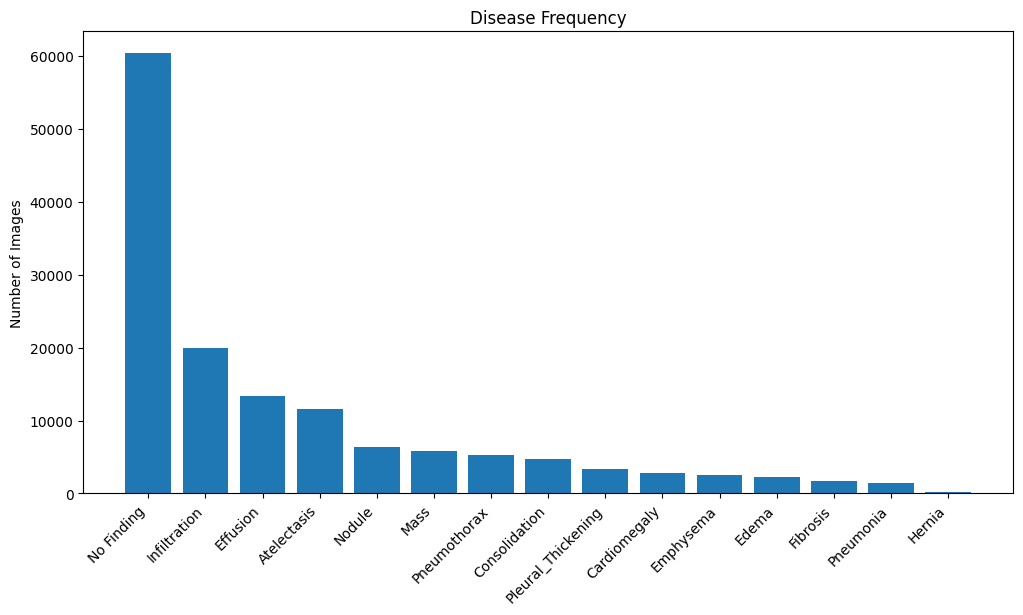

In [22]:
# ============================================================
# Sprint 02 : Disease Frequency
# ============================================================

from collections import Counter

counter = Counter()

for labels in metadata_df["Finding Labels"]:
    counter.update(labels.split("|"))

label_df = (
    pd.DataFrame(counter.items(), columns=["Disease", "Count"])
      .sort_values("Count", ascending=False)
      .reset_index(drop=True)
)

display(label_df)

plt.figure(figsize=(12,6))

plt.bar(label_df["Disease"], label_df["Count"])

plt.xticks(rotation=45, ha="right")

plt.title("Disease Frequency")

plt.ylabel("Number of Images")

plt.show()

LABEL CARDINALITY
Average diseases/image : 0.72
Maximum diseases/image : 9

Distribution



Finding Labels
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64

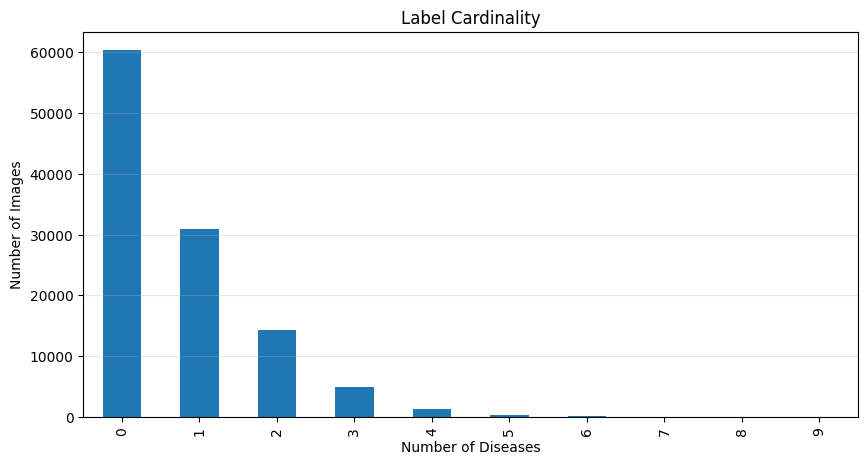

In [23]:
# ============================================================
# Sprint 02 : Label Cardinality Analysis
# ============================================================

label_counts = metadata_df["Finding Labels"].apply(
    lambda x: 0 if x == "No Finding" else len(x.split("|"))
)

print("=" * 70)
print("LABEL CARDINALITY")
print("=" * 70)

print(f"Average diseases/image : {label_counts.mean():.2f}")

print(f"Maximum diseases/image : {label_counts.max()}")

print("\nDistribution\n")

display(label_counts.value_counts().sort_index())

plt.figure(figsize=(10,5))

label_counts.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Diseases")

plt.ylabel("Number of Images")

plt.title("Label Cardinality")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:
# ============================================================
# Sprint 02 : Inspect First Image Folder
# ============================================================

first_folder = IMAGE_FOLDERS[0]

print("=" * 70)
print("FIRST IMAGE FOLDER")
print("=" * 70)

print(first_folder)

print("\nContents:\n")

for item in sorted(first_folder.iterdir())[:20]:
    print(item.name)

FIRST IMAGE FOLDER
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001

Contents:

images


In [26]:
# ============================================================
# Sprint 02 : Recursive PNG Discovery
# ============================================================

png_files = list(PROJECT_ROOT.rglob("*.png"))

print("=" * 70)
print("PNG DISCOVERY")
print("=" * 70)

print(f"PNG files discovered : {len(png_files):,}")

print("\nFirst five PNGs:\n")

for img in png_files[:5]:
    print(img)

PNG DISCOVERY
PNG files discovered : 112,120

First five PNGs:

/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004833_016.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006260_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004911_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004186_007.png


In [27]:
# ============================================================
# Sprint 02 : Metadata ↔ Filesystem Integrity Audit
# ============================================================

metadata_images = set(metadata_df["Image Index"])

filesystem_images = {img.name for img in png_files}

missing_files = metadata_images - filesystem_images
orphan_files = filesystem_images - metadata_images

print("=" * 70)
print("DATASET INTEGRITY AUDIT")
print("=" * 70)

print(f"Metadata Images   : {len(metadata_images):,}")
print(f"Filesystem Images : {len(filesystem_images):,}")

print(f"\nMissing Files     : {len(missing_files)}")
print(f"Orphan Files      : {len(orphan_files)}")

if len(missing_files) == 0 and len(orphan_files) == 0:
    print("\n✅ Metadata and filesystem are perfectly synchronized.")
else:
    print("\n❌ Dataset mismatch detected.")

DATASET INTEGRITY AUDIT
Metadata Images   : 112,120
Filesystem Images : 112,120

Missing Files     : 0
Orphan Files      : 0

✅ Metadata and filesystem are perfectly synchronized.


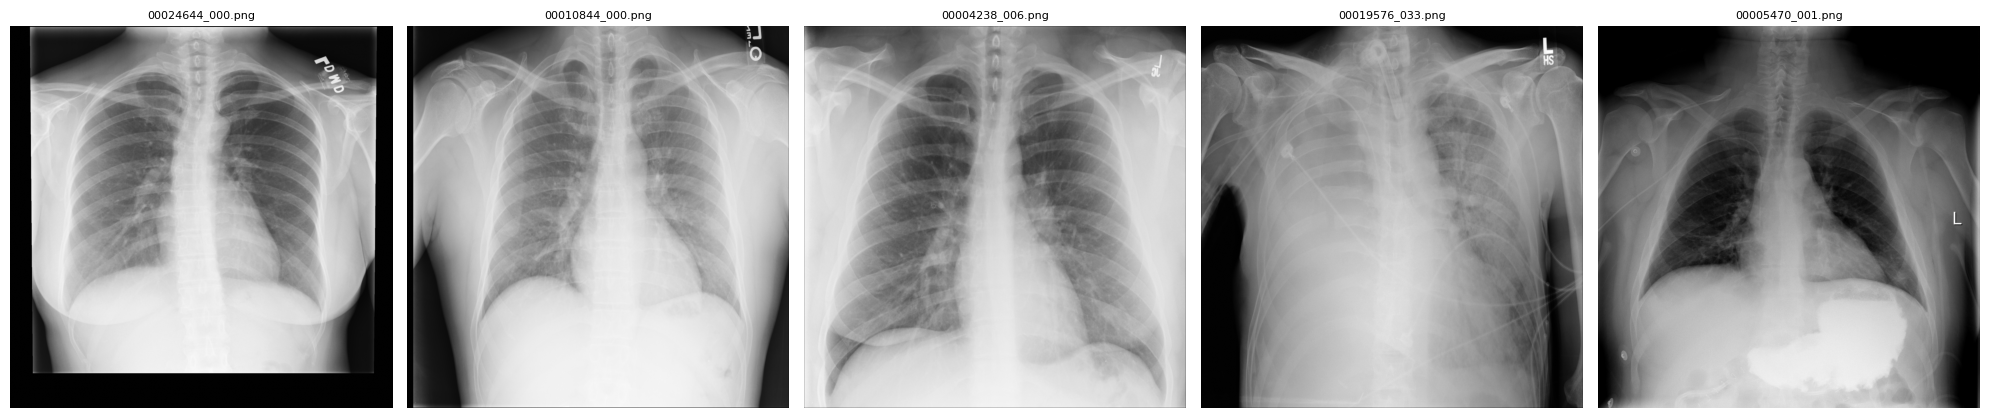

In [28]:
# ============================================================
# Sprint 02 : Visual Dataset Inspection
# ============================================================

import random

fig, axes = plt.subplots(1, 5, figsize=(20,5))

samples = random.sample(png_files, 5)

for ax, img_path in zip(axes, samples):

    image = Image.open(img_path)

    ax.imshow(image, cmap="gray")

    ax.set_title(img_path.name, fontsize=8)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Sprint 02 : Image Resolution Audit
# ============================================================

from collections import Counter

resolution_counter = Counter()

for img_path in png_files[:2000]:
    with Image.open(img_path) as img:
        resolution_counter[img.size] += 1

print("=" * 70)
print("IMAGE RESOLUTION AUDIT (Sample of 2,000 Images)")
print("=" * 70)

print(f"Unique resolutions found: {len(resolution_counter)}\n")

resolution_df = (
    pd.DataFrame(
        resolution_counter.items(),
        columns=["Resolution", "Count"]
    )
    .sort_values("Count", ascending=False)
)

display(resolution_df.head(10))

IMAGE RESOLUTION AUDIT (Sample of 2,000 Images)
Unique resolutions found: 1



,Resolution,Count
0,"(1024, 1024)",2000
